In [1]:
# Import libraries
import numpy as np
import math
import random
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm # linear regression
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from DE_GO_analysis import analyze_pla_marker_with_DE
import scanpy as sc
from gprofiler import GProfiler
import os



#*****
mpl.rcdefaults()
# Set font to be arial
mpl.rc('font', **{'sans-serif':'Arial', 'size':12})
mpl.rcParams['mathtext.rm'] = 'sans' # to have non-italic greek letter, use r'$\mathrm{\alpha}$', does NOT work with f-string
mpl.rcParams['axes.titlesize'] = 12
# Set default tick size
mpl.rcParams['xtick.major.size'] = 5.5
mpl.rcParams['ytick.major.size'] = 5.5
mpl.rcParams['xtick.minor.size'] = 2.5
mpl.rcParams['ytick.minor.size'] = 2.5
# Default legend settings
mpl.rcParams['legend.fancybox'] = False
mpl.rcParams['legend.edgecolor'] = 'k'

#to store text as text, not as path
new_rc_params = {'text.usetex': False,
                 "svg.fonttype": 'none'}
mpl.rcParams.update(new_rc_params)
#*****
# Seed number
np.random.seed(2025)
random.seed(2025)

In [2]:
# Load the .h5ad file
adata_rna_gc_follicle = sc.read("combined_GC_follicle_mRNA_ABD.h5ad")
adata_fraction_oeverlap_gc_follicle = sc.read("combined_weighted_fraction_ABD_data_remove_batch_effect.h5ad")

[INFO] Filtering by batch: ['A1']
adata_pla shape: (1313, 528)
adata_rna shape: (1313, 21398)


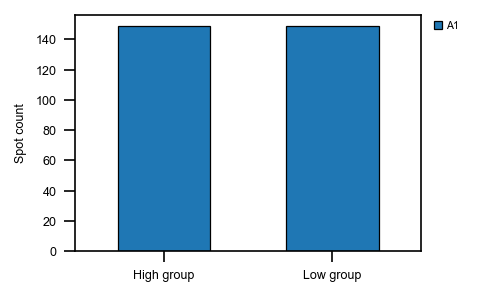

/Users/huiliw/Desktop/postdoc /spatial_visium/data/sequencing_data/2502_spatial_sequencing/20250228/DE_GO_analysis.py:158: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = adata_high.concatenate(


[INFO] Volcano saved to de_output/CD21_CD35_A1_GC/CD21_CD35_A1_GC_volcano.svg


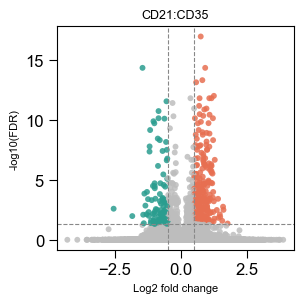

In [3]:
CD21_CD35_GC_results_A1 = analyze_pla_marker_with_DE(
    adata_pla=adata_fraction_oeverlap_gc_follicle,
    adata_rna=adata_rna_gc_follicle,
    pla_marker="CD21:CD35",
    low_pct=20,
    high_pct=20,
    min_cells=30,
    cluster_key="mrna_annotation",
    batch_filter=['A1', ],
    fc_thresh=0.5,
    cluster_labels=["Light zone", "Dark zone"],
    output_prefix="CD21_CD35_A1_GC"
)

[INFO] Filtering by batch: ['B1']
adata_pla shape: (1536, 528)
adata_rna shape: (1536, 21398)


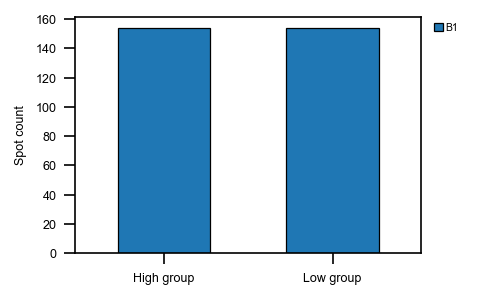

/Users/huiliw/Desktop/postdoc /spatial_visium/data/sequencing_data/2502_spatial_sequencing/20250228/DE_GO_analysis.py:158: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = adata_high.concatenate(


[INFO] Volcano saved to de_output/CD21_CD35_B1_GC/CD21_CD35_B1_GC_volcano.svg


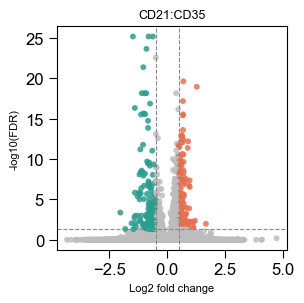

In [21]:
CD21_CD35_GC_results_B1 = analyze_pla_marker_with_DE(
    adata_pla=adata_fraction_oeverlap_gc_follicle,
    adata_rna=adata_rna_gc_follicle,
    pla_marker="CD21:CD35",
    low_pct=20,
    high_pct=20,
    min_cells=30,
    cluster_key="mrna_annotation",
    batch_filter=['B1', ],
    fc_thresh=0.5,
    cluster_labels=["Light zone", "Dark zone"],
    output_prefix="CD21_CD35_B1_GC"
)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
from matplotlib.patches import Patch
from matplotlib.colors import Normalize, TwoSlopeNorm, LinearSegmentedColormap

def plot_deg_heatmap_from_df(
    deg_df: pd.DataFrame,
    adata_rna,
    top_n: int = 50,
    group_key: str = "mrna_annotation",
    scale: bool = True,
    cell_level: bool = False,
    figsize=(4, 5),
    title: str | None = None,
    cmap: str | LinearSegmentedColormap = "paper_orange_blue",
    center: float = 0,
    zscore_range=(-1, 2),
    group_palette: dict | None = None,
    batch_key: str = "batch",
    batch_palette: dict | None = None,
    save_path: str | None = None,
    p_adj_thresh: float = 0.05,
    exclude_ribosomal: bool = True,
    use_two_slope: bool = True,
    norm_center: float = 0.0,
    # NEW —— only hide/show batch on the plot
    show_batch: bool = False,
):
    # colormap
    if isinstance(cmap, str) and cmap == "paper_orange_blue":
        cmap = LinearSegmentedColormap.from_list(
            "paper_orange_blue",
            ["#6BAED6", "#D9ECF7", "#FFFFFF", "#F4B89B", "#E07A5F"],
            N=256
        )

    # checks
    required_cols = {"names", "logfoldchanges", "pvals_adj"}
    if not required_cols.issubset(deg_df.columns):
        missing = required_cols - set(deg_df.columns)
        raise ValueError(f"deg_df missing required columns: {missing}")

    df = deg_df.copy()
    if exclude_ribosomal:
        df = df[~df["names"].str.startswith(("RPS", "RPL"), na=False)]

    sig_up = df[(df["pvals_adj"] < p_adj_thresh) & (df["logfoldchanges"] > 0)].copy()
    if sig_up.empty:
        print("⚠️ No significant upregulated DEGs after filtering.")
        return

    top_tbl = sig_up.sort_values("logfoldchanges", ascending=False).head(top_n)
    top_tbl = top_tbl[top_tbl["names"].isin(adata_rna.var_names)]
    if top_tbl.empty:
        print("⚠️ None of the selected genes are in adata.var_names.")
        return
    top_tbl = top_tbl.sort_values(["pvals_adj", "logfoldchanges"], ascending=[True, False])

    gene_list = top_tbl["names"].tolist()
    selection_note = (
        f"{len(gene_list)} Up (adjP<{p_adj_thresh}); "
        "selected by logFC within significant genes, ordered by adjP"
    )

    # expression matrix
    expr = (adata_rna.raw[:, gene_list].X if adata_rna.raw is not None
            else adata_rna[:, gene_list].X)
    if scipy.sparse.issparse(expr):
        expr = expr.toarray()
    expr_df = pd.DataFrame(expr, index=adata_rna.obs_names, columns=gene_list)

    # obs & keys
    obs_df = adata_rna.obs.copy()
    if group_key not in obs_df.columns:
        raise KeyError(f"`group_key='{group_key}'` not found in adata_rna.obs.")
    has_batch = batch_key in obs_df.columns

    # build matrix
    if cell_level:
        # order columns: group then batch (for blocks); batch will be hidden if show_batch=False
        sort_cols = [group_key] + ([batch_key] if has_batch else [])
        obs_df = obs_df.sort_values(sort_cols)
        expr_df = expr_df.loc[obs_df.index]
        data_matrix = expr_df.T

        # column colors
        group_series = obs_df[group_key].astype(str)
        group_values = list(dict.fromkeys(group_series.tolist()))

        if group_palette is None:
            lower = [g.lower() for g in group_values]
            if "high" in lower and "low" in lower:
                group_palette = {g: ("red" if g.lower()=="high" else "blue" if g.lower()=="low"
                                     else sns.color_palette("Set2", len(group_values))[group_values.index(g)])
                                 for g in group_values}
            else:
                group_palette = dict(zip(group_values, sns.color_palette("Set2", len(group_values))))

        if has_batch and show_batch:
            batch_series = obs_df[batch_key].astype(str)
            batch_values = list(dict.fromkeys(batch_series.tolist()))
            if batch_palette is None:
                batch_palette = dict(zip(batch_values, sns.color_palette("Pastel1", len(batch_values))))
            col_colors = pd.DataFrame({
                "Group": group_series.map(group_palette),
                "Batch": batch_series.map(batch_palette)
            }, index=obs_df.index)
        else:
            # HIDE batch on the plot: only keep Group color bar
            col_colors = pd.DataFrame({"Group": group_series.map(group_palette)}, index=obs_df.index)
    else:
        expr_df[group_key] = obs_df[group_key]
        data_matrix = expr_df.groupby(group_key).mean().T
        col_colors = None

    data_matrix = data_matrix.loc[gene_list]

    # z-score
    if scale:
        data_matrix = data_matrix.subtract(data_matrix.mean(axis=1), axis=0)
        data_matrix = data_matrix.divide(data_matrix.std(axis=1) + 1e-9, axis=0)

    heatmap_kwargs = {"cmap": cmap}
    if zscore_range is not None:
        vmin, vmax = zscore_range
        if use_two_slope:
            heatmap_kwargs["norm"] = TwoSlopeNorm(vmin=vmin, vcenter=norm_center, vmax=vmax)
        else:
            heatmap_kwargs.update(vmin=vmin, vmax=vmax)

    y_font = max(5, min(9, 180 / max(1, len(gene_list))))

    # plotting
    if cell_level:
        cg = sns.clustermap(
            data_matrix, row_cluster=False, col_cluster=False,
            col_colors=col_colors, xticklabels=False, yticklabels=True,
            figsize=figsize, cbar_pos=None, **heatmap_kwargs
        )

        # colorbar
        if "norm" in heatmap_kwargs:
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=heatmap_kwargs["norm"])
        else:
            sm = plt.cm.ScalarMappable(
                cmap=cmap,
                norm=Normalize(vmin=heatmap_kwargs.get("vmin", np.nanmin(data_matrix.values)),
                               vmax=heatmap_kwargs.get("vmax", np.nanmax(data_matrix.values)))
            )
        sm.set_array([])
        cbar_ax = cg.fig.add_axes([0.99, 0.35, 0.012, 0.22])
        cbar = cg.fig.colorbar(sm, cax=cbar_ax, orientation="vertical")
        cbar.set_label("Z-score" if scale else "Expression")

        # title
        cg.fig.suptitle(title or f"Top DEGs (UP only) — {selection_note}", y=0.98, fontsize=12)

        # y tick font
        for lbl in cg.ax_heatmap.get_yticklabels():
            lbl.set_fontsize(y_font)

        # legend: only Group unless show_batch=True
        leg_ax = cg.fig.add_axes([0.98, 0.12, 0.1, 0.1]); leg_ax.axis("off")
        handles = [Patch(facecolor=group_palette[g], label=g) for g in group_values]
        legend_title = group_key
        if has_batch and show_batch:
            batch_values = list(dict.fromkeys(obs_df[batch_key].astype(str).tolist()))
            handles += [Patch(facecolor=batch_palette[b], label=b) for b in batch_values]
            legend_title = f"{group_key} / {batch_key}"
        leg_ax.legend(handles=handles, title=legend_title, loc="center",
                      frameon=False, ncol=1, fontsize=8, title_fontsize=9)

        # optional separators between groups
        boundaries, last = [], None
        for i, g in enumerate(obs_df[group_key].tolist()):
            if g != last and i != 0:
                boundaries.append(i)
            last = g
        for x in boundaries:
            cg.ax_heatmap.axvline(x, color="white", lw=0.6, alpha=0.9)

        cg.fig.subplots_adjust(left=0.15, right=0.86, top=0.93, bottom=0.05)

        if save_path:
            cg.fig.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"✅ Heatmap saved to {save_path}")
        plt.show()
    else:
        plt.figure(figsize=figsize)
        ax = sns.heatmap(
            data_matrix, xticklabels=True, yticklabels=True, linewidths=0,
            cbar_kws={"label": "Z-score" if scale else "Expression"},
            **heatmap_kwargs
        )
        ax.set_title(title or f"Top DEGs (UP only) — {selection_note}")
        ax.set_xlabel("Group"); ax.set_ylabel("Gene")
        plt.yticks(fontsize=y_font)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"✅ Heatmap saved to {save_path}")
        plt.show()


✅ Heatmap saved to Figures/Fig-5e.svg


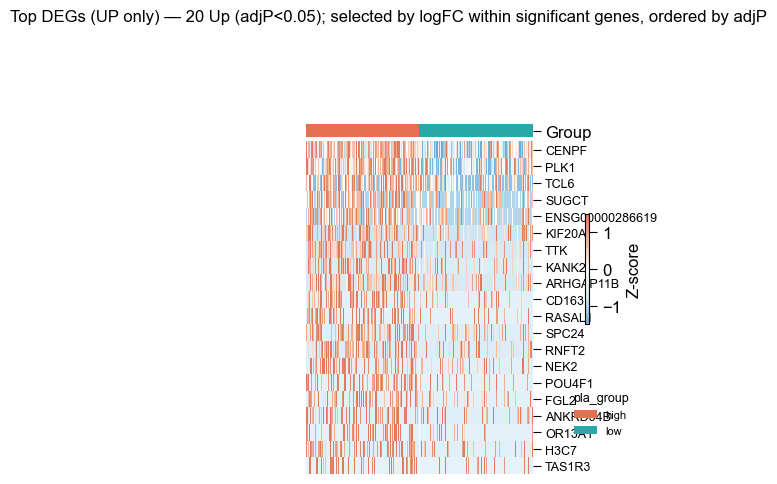

In [6]:
plot_deg_heatmap_from_df(
  deg_df=CD21_CD35_GC_results_A1['deg_df'],
    adata_rna=CD21_CD35_GC_results_A1['adata_combined'],
    top_n=20,
    cell_level=True,
    group_key="pla_group",
    # batch_key="batch",
    cmap="paper_orange_blue",     
    zscore_range=(-1.5,1.5), 
     show_batch=False,
    use_two_slope=True,           
    norm_center=0.0,
    group_palette={"high":"#E76F51", "low":"#2AA8A8"},
    save_path = 'Figures/Fig-5e.svg',
)


✅ Heatmap saved to Figures/CD21_CD35_DE_B1.svg


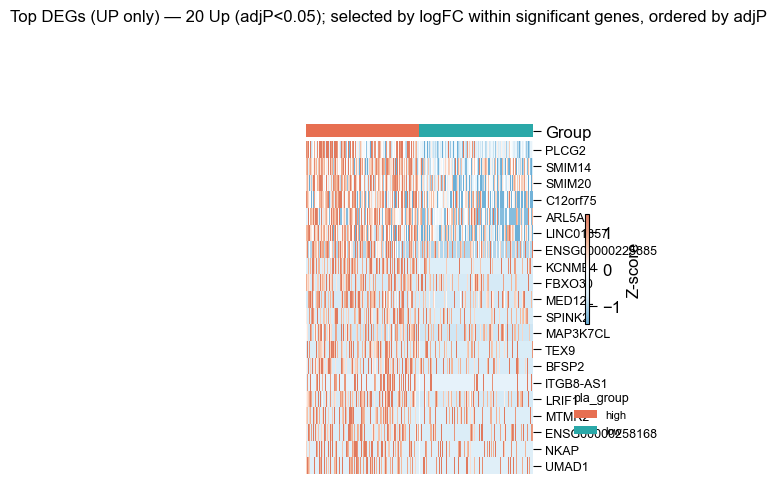

In [22]:
plot_deg_heatmap_from_df(
  deg_df=CD21_CD35_GC_results_B1['deg_df'],
    adata_rna=CD21_CD35_GC_results_B1['adata_combined'],
    top_n=20,
    cell_level=True,
    group_key="pla_group",
    # batch_key="batch",
    cmap="paper_orange_blue",     
    zscore_range=(-1.5,1.5), 
     show_batch=False,
    use_two_slope=True,           
    norm_center=0.0,
    group_palette={"high":"#E76F51", "low":"#2AA8A8"},
    save_path = 'Figures/Extended-Fig-12c.svg',
)


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import gseapy as gp

def run_enrichment_for_gene_sets(gene_sets_dict, gene_set_library="KEGG_2021_Human", output_dir="enrichr_output"):
    """
    Run Enrichr-based pathway enrichment using gseapy for multiple gene sets.
    """
    os.makedirs(output_dir, exist_ok=True)
    enrichment_results = {}

    for name, gene_list in gene_sets_dict.items():
        if not gene_list:
            print(f"⚠️ Skipping {name}: gene list is empty.")
            continue
        print(f"🔍 Running enrichment for: {name} (n={len(gene_list)})")
        try:
            enr = gp.enrichr(
                gene_list=list(gene_list),
                gene_sets=gene_set_library,
                organism="Human",
                outdir=os.path.join(output_dir, name),
                no_plot=True,
                cutoff=0.5
            )
            enrichment_results[name] = enr.results
        except Exception as e:
            print(f"❌ Failed on {name}: {e}")
    
    return enrichment_results


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_enrichment_bubble(df, label='Up_overlap', top_n=20, min_intersect_size=1, save_path=None):
    """
    Plot an enrichment bubble chart with fixed bubble size (no Intersection legend).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing enrichment results with columns ['Term', 'Overlap', 'Adjusted P-value'].
    label : str
        Label for the plot title.
    top_n : int
        Number of top terms to display.
    min_intersect_size : int
        Minimum intersection size to include in the plot.
    save_path : str or None
        File path to save the figure (e.g., 'plot.png'). If None, the plot is only displayed.
    """
    required_cols = ['Term', 'Overlap', 'Adjusted P-value']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")
    if df.empty:
        print(f"⚠️ No enrichment results to plot for {label}")
        return

    # Parse intersection size and term size from the "Overlap" column
    try:
        df[['intersect_size', 'term_size']] = df['Overlap'].str.split('/', expand=True).astype(int)
    except Exception as e:
        raise ValueError(f"❌ Failed to parse 'Overlap' column: {e}")
    
    # Calculate Gene Ratio and -log10(Adjusted P-value)
    df['GeneRatio'] = df['intersect_size'] / df['term_size']
    df['neg_log10_p'] = -np.log10(df['Adjusted P-value'] + 1e-300)

    # Apply filters
    df = df[df['intersect_size'] >= min_intersect_size]
    df = df.sort_values('neg_log10_p', ascending=False).head(top_n).copy()
    if df.empty:
        print(f"⚠️ No terms passed filtering for {label}")
        return

    df['y_order'] = np.arange(len(df))

    # Create the figure
    plt.figure(figsize=(6, 4))
    norm = Normalize(vmin=df['neg_log10_p'].min(), vmax=df['neg_log10_p'].max())
    sm = ScalarMappable(cmap='RdBu_r', norm=norm)
    sm.set_array([])

    ax = plt.gca()

    # Scatter plot with fixed bubble size
    sns.scatterplot(
        data=df,
        x='GeneRatio',
        y='y_order',
        s=100,  # Fixed bubble size
        hue='neg_log10_p',
        palette='RdBu_r',
        edgecolor='black',
        linewidth=0.5,
        legend=False,  # No Intersection legend
        ax=ax
    )

    # Y-axis labels
    ax.set_yticks(df['y_order'])
    ax.set_yticklabels(df['Term'])
    ax.invert_yaxis()

    # Colorbar for p-values
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('-log10(Adjusted P-value)')

    # Axis labels and title
    plt.xlabel('Gene Ratio')
    plt.ylabel('Enriched Term')
    plt.title(f'Enrichment Bubble Plot – {label}')

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()

    # Save figure if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Bubble plot saved to {save_path}")

    plt.show()


In [9]:
deg_df_A1 = CD21_CD35_GC_results_A1['deg_df']

In [10]:
deg_df_B1 = CD21_CD35_GC_results_B1['deg_df']

In [11]:
# Filter and sort while keeping needed columns
up_df_A1 = (
    deg_df_A1[(deg_df_A1["logfoldchanges"] > 0.5) & (deg_df_A1["pvals_adj"] < 0.05)]
    .loc[:, ["names", "logfoldchanges", "pvals_adj"]]
    .sort_values("logfoldchanges", ascending=False)   # Up: largest to smallest
)

down_df_A1 = (
    deg_df_A1[(deg_df_A1["logfoldchanges"] < -0.5) & (deg_df_A1["pvals_adj"] < 0.05)]
    .loc[:, ["names", "logfoldchanges", "pvals_adj"]]
    .sort_values("logfoldchanges", ascending=True)    # Down: smallest to largest
)


# Gene-name lists (e.g., for GSEA)
gene_sets_names_A1 = {
    "Up": up_df_A1["names"].tolist(),
    "Down": down_df_A1["names"].tolist(),
}

# Ordered mapping: gene -> logFC (dict preserves insertion order in Py3.7+)
gene_sets_logfc_A1 = {
    "Up": dict(zip(up_df_A1["names"], up_df_A1["logfoldchanges"])),
    "Down": dict(zip(down_df_A1["names"], down_df_A1["logfoldchanges"])),
}

# Combined ranked table with a direction label (handy for saving/plotting)
ranked_deg_df_A1 = pd.concat(
    [up_df_A1.assign(direction="Up"), down_df_A1.assign(direction="Down")],
    ignore_index=True
)



In [12]:
# Filter and sort while keeping needed columns
up_df_B1 = (
    deg_df_B1[(deg_df_B1["logfoldchanges"] > 0.5) & (deg_df_B1["pvals_adj"] < 0.05)]
    .loc[:, ["names", "logfoldchanges", "pvals_adj"]]
    .sort_values("logfoldchanges", ascending=False)   # Up: largest to smallest
)

down_df_B1 = (
    deg_df_B1[(deg_df_B1["logfoldchanges"] < -0.5) & (deg_df_B1["pvals_adj"] < 0.05)]
    .loc[:, ["names", "logfoldchanges", "pvals_adj"]]
    .sort_values("logfoldchanges", ascending=True)    # Down: smallest to largest
)


# Gene-name lists (e.g., for GSEA)
gene_sets_names_B1 = {
    "Up": up_df_B1["names"].tolist(),
    "Down": down_df_B1["names"].tolist(),
}

# Ordered mapping: gene -> logFC (dict preserves insertion order in Py3.7+)
gene_sets_logfc_B1 = {
    "Up": dict(zip(up_df_B1["names"], up_df_B1["logfoldchanges"])),
    "Down": dict(zip(down_df_B1["names"], down_df_B1["logfoldchanges"])),
}

# Combined ranked table with a direction label (handy for saving/plotting)
ranked_deg_df_B1 = pd.concat(
    [up_df_B1.assign(direction="Up"), down_df_B1.assign(direction="Down")],
    ignore_index=True
)



🔍 Running enrichment for: Up (n=278)
🔍 Running enrichment for: Down (n=97)
✅ Bubble plot saved to Figures/Fig-5f.svg


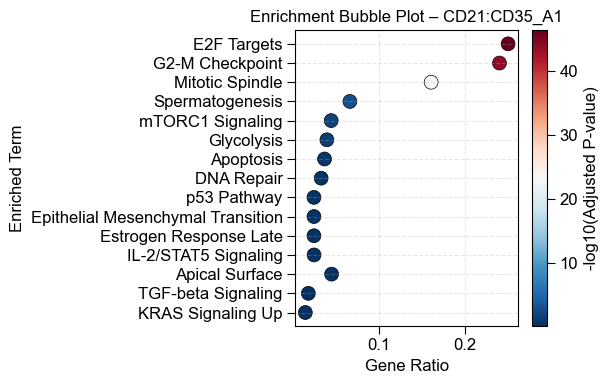

In [19]:
enrichment_results = run_enrichment_for_gene_sets(
    gene_sets_dict=gene_sets_names_A1,
    gene_set_library="MSigDB_Hallmark_2020",
    output_dir="enrichr_output_CD21_CD35_GC"
)
plot_enrichment_bubble(enrichment_results['Up'], label='CD21:CD35_A1', top_n=15,save_path='Figures/Fig-5f.svg' )#


🔍 Running enrichment for: Up (n=187)
🔍 Running enrichment for: Down (n=188)
✅ Bubble plot saved to Figures/CD21_CD35_UP_GO_B1.svg


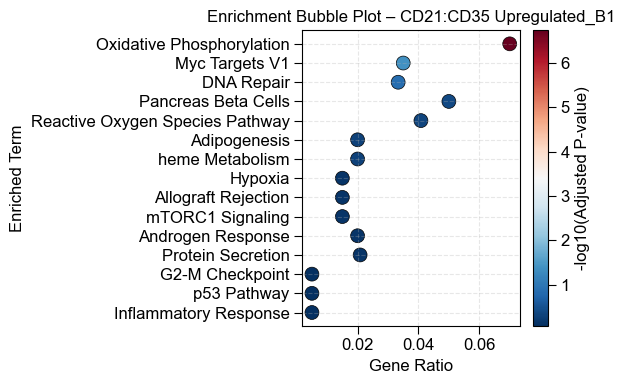

In [20]:
enrichment_results = run_enrichment_for_gene_sets(
    gene_sets_dict=gene_sets_names_B1,
    gene_set_library="MSigDB_Hallmark_2020",
    output_dir="enrichr_output_CD21_CD35_GC"
)
plot_enrichment_bubble(enrichment_results['Up'], label='CD21:CD35 Upregulated_B1', top_n=15,save_path='Figures/Extended-Fig12-d.svg' )


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def analyze_pla_volcano_from_raw(
    adata, target_protein, cluster1, cluster2,
    fc_thresh=1.0,
    fdr_thresh=0.05,                   
    annotation_key="mrna_annotation",
    sep=":",
    pseudo=1e-6,
    save_path=None, title=None,
    label_significant=True,           
    label_fontsize=7
):
    """
    Volcano plot comparing PLA pairs involving the target protein.
    Y-axis uses -log10(raw P-value); significance is judged by BH-adjusted FDR.
    Always shows the plot; if save_path is given, also saves to file.
    """
    # 1) build dataframe
    raw_df = pd.DataFrame(
        adata.raw.X, columns=adata.raw.var_names, index=adata.obs_names
    )
    raw_df[annotation_key] = adata.obs[annotation_key].values

    def has_target(col):
        if col == annotation_key: return False
        if sep in col:
            a, b = col.split(sep, 1)
            return (a == target_protein) or (b == target_protein)
        return False

    pla_cols = [c for c in raw_df.columns if has_target(c)]
    results = []
    for col in pla_cols:
        g1 = raw_df.loc[raw_df[annotation_key] == cluster1, col].values
        g2 = raw_df.loc[raw_df[annotation_key] == cluster2, col].values
        if (g1.size < 3) or (g2.size < 3):
            continue
        _, pval = mannwhitneyu(g1, g2, alternative="two-sided")
        log2fc = np.log2((g1.mean() + pseudo) / (g2.mean() + pseudo))
        results.append({"PLA_pair": col, "log2FC": log2fc, "pval": float(pval)})

    volcano_df = pd.DataFrame(results)
    if volcano_df.empty:
        print("No valid PLA pairs found.")
        return {"deg_df": volcano_df}

    # 2) BH (FDR) correction
    volcano_df["pval_adj"] = multipletests(volcano_df["pval"], method="fdr_bh")[1]

    # 3) categories (based on FDR) + plotting values
    volcano_df["significant"] = (volcano_df["pval_adj"] < fdr_thresh) & \
                                (np.abs(volcano_df["log2FC"]) > fc_thresh)
    volcano_df["neglog10_pval"] = -np.log10(np.clip(volcano_df["pval"], 1e-300, 1.0))

    # 4) plot
    plt.figure(figsize=(3.2, 3.2))
    for _, row in volcano_df.iterrows():
        color = "red" if row["significant"] else "gray"
        plt.scatter(row["log2FC"], row["neglog10_pval"], color=color, s=36)

    # thresholds
    plt.axhline(-np.log10(fdr_thresh), linestyle="--", color="gray", lw=0.8)
    plt.axvline(fc_thresh,  linestyle="--", color="gray", lw=0.8)
    plt.axvline(-fc_thresh, linestyle="--", color="gray", lw=0.8)

    # labels for significant points (optional)
    if label_significant:
        sig = volcano_df[volcano_df["significant"]]
        for _, r in sig.iterrows():
            plt.text(r["log2FC"], r["neglog10_pval"], r["PLA_pair"],
                     fontsize=label_fontsize, ha="center", va="bottom", color="black")

    plt.xlabel("Log2 fold change")
    plt.ylabel("-log10(P-value)")
    plt.title(title or f"{target_protein}-related PLA pairs")
    plt.tight_layout()

    # save AND show
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"✅ Volcano plot saved to {save_path}")
    plt.show()

    return {"deg_df": volcano_df}


✅ Volcano plot saved to Figures/Fig-6h.svg


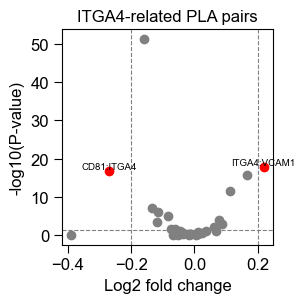

{'deg_df':         PLA_pair    log2FC          pval      pval_adj  significant  \
 0    CD11a:ITGA4 -0.014405  3.740444e-01  5.411192e-01        False   
 1    CD147:ITGA4 -0.021622  4.310824e-01  5.747766e-01        False   
 2     CD19:ITGA4 -0.015692  9.692908e-01  9.692908e-01        False   
 3     CD20:ITGA4 -0.074855  2.512790e-02  5.743520e-02        False   
 4     CD21:ITGA4 -0.045413  9.449403e-02  1.889881e-01        False   
 5     CD23:ITGA4 -0.389697  9.469852e-01  9.692908e-01        False   
 6     CD24:ITGA4  0.011907  1.348282e-01  2.396946e-01        False   
 7     CD27:ITGA4  0.035954  1.025456e-01  1.930270e-01        False   
 8    CD279:ITGA4 -0.060216  1.986885e-02  4.890793e-02        False   
 9     CD28:ITGA4  0.067542  7.834581e-02  1.671377e-01        False   
 10    CD29:ITGA4 -0.158204  5.531016e-52  1.769925e-50        False   
 11     CD3:ITGA4  0.004888  6.700759e-01  7.658010e-01        False   
 12    CD32:ITGA4 -0.115571  1.109303e-06  5.071097e-0

In [32]:
analyze_pla_volcano_from_raw(
    adata=adata_fraction_oeverlap_gc_follicle,
    target_protein="ITGA4",
     fc_thresh=0.2,
    fdr_thresh=0.05, 
    cluster1="Light zone", cluster2="Dark zone",
    label_significant=True,
    save_path="Figures/Fig-6h.svg",
)